#  机器学习期末复习笔记：K-means 算法与严格数学证明

## 一、 核心概念与数学建模

### 1. 任务性质
K-means 属于**无监督学习（Unsupervised Learning）**中的**聚类（Clustering）**算法。其目标是在无标签的数据集 $\mathcal{D} = \{x_1, x_2, \dots, x_N\}$（其中 $x_n \in \mathbb{R}^D$）中，自动发现 $K$ 个潜在的几何结构簇。

### 2. 数学变量定义
* **簇中心（Centroids）**：记为 $\mu_k \in \mathbb{R}^D$，$k \in \{1, 2, \dots, K\}$。
* **分配变量（Assignments）**：记为 $z_n \in \{1, 2, \dots, K\}$，表示样本 $x_n$ 归属的簇标签。
* **指示函数（1-of-K 表示法）**：
    $$\mathbb{I}(z_n = k) = \begin{cases} 1, & \text{若 } z_n = k \\ 0, & \text{若 } z_n \neq k \end{cases}$$

### 3. 目标函数（畸变函数 / Distortion Function）
K-means 试图最小化所有样本点到其对应簇中心的欧氏距离平方和：
$$J(\mu, z) = \sum_{n=1}^N ||x_n - \mu_{z_n}||_2^2 = \sum_{k=1}^K \sum_{n=1}^N \mathbb{I}(z_n = k) ||x_n - \mu_k||_2^2$$

---

## 二、 优化算法：劳埃德算法（Lloyd's Algorithm）

由于目标函数同时包含离散变量 $z$ 和连续变量 $\mu$，属于非凸优化问题。算法采用**交替下降法（Alternating Descent）**策略：

1.  **初始化**：随机选择 $K$ 个点作为初始簇中心 $\mu^{(0)}$。
2.  **交替迭代**直至收敛：
    * **Step 1（更新分配 $z$）**：固定中心 $\mu$，将点分配给最近的中心。
        $$z_n^{(t)} = \arg\min_{k} ||x_n - \mu_k^{(t-1)}||_2^2$$
    * **Step 2（更新中心 $\mu$）**：固定分配 $z$，将中心移动到该簇内所有点的算术平均值处。
        $$\mu_k^{(t)} = \arg\min_{\mu_k} \sum_{n \in \mathcal{C}_k} ||x_n - \mu_k||_2^2$$

---

## 三、 核心定理与期末必考证明

### 定理 1：均值极值定理（簇中心的更新依据）
**【定理表述】**：在固定样本归属 $z$ 的条件下，使得局部目标函数 $J_k$ 最小的新中心 $\mu_k$ 由该簇内所有样本的算术平均值给出。

**【严格证明】（以一维空间 $D=1$ 为例）**
设簇 $\mathcal{C}_k$ 中的样本数量为 $N_k$，对应的局部目标函数为：
$$J_k(\mu_k) = \sum_{i \in \mathcal{C}_k} (x_i - \mu_k)^2$$

1.  **求一阶导数（寻找驻点）**：
    利用复合函数求导法则（链式法则）对未知数 $\mu_k$ 求偏导：
    $$\frac{\partial J_k}{\partial \mu_k} = \sum_{i \in \mathcal{C}_k} 2(x_i - \mu_k) \cdot (-1) = -2\sum_{i \in \mathcal{C}_k} x_i + 2\sum_{i \in \mathcal{C}_k} \mu_k$$
    因为 $\mu_k$ 相对于求和变量 $i$ 是常数，所以 $\sum_{i \in \mathcal{C}_k} \mu_k = N_k \mu_k$。带入得：
    $$\frac{\partial J_k}{\partial \mu_k} = -2\sum_{i \in \mathcal{C}_k} x_i + 2N_k\mu_k$$
    令一阶导数为 $0$：
    $$-2\sum_{i \in \mathcal{C}_k} x_i + 2N_k\mu_k = 0 \implies \mu_k^* = \frac{1}{N_k}\sum_{i \in \mathcal{C}_k} x_i$$

2.  **求二阶导数（验证极小值）**：
    $$\frac{\partial^2 J_k}{\partial \mu_k^2} = \frac{\partial}{\partial \mu_k}\left(-2\sum_{i \in \mathcal{C}_k} x_i + 2N_k\mu_k\right) = 2N_k$$
    由于样本数 $N_k > 0$，故二阶导数恒大于 $0$。根据多元函数极值判别法，目标函数为严格凸函数，驻点 $\mu_k^*$ 必为全局极小值点。   *(证毕)* $\blacksquare$

---

### 定理 2：劳埃德算法的收敛性定理
**【定理表述】**：K-means 算法在有限步迭代内必然完全收敛。

**【严格证明】**
1.  **单调性**：
    * 在 Step 1 中，固定 $\mu^{(t-1)}$ 优化 $z^{(t)}$，因为 $z^{(t)}$ 是使距离最小的选择，故：$J(\mu^{(t-1)}, z^{(t)}) \le J(\mu^{(t-1)}, z^{(t-1)})$。
    * 在 Step 2 中，固定 $z^{(t)}$ 优化 $\mu^{(t)}$，根据定理 1（均值是全局极小值），故：$J(\mu^{(t)}, z^{(t)}) \le J(\mu^{(t-1)}, z^{(t)})$。
    * 串联得：$J(\mu^{(t)}, z^{(t)}) \le J(\mu^{(t-1)}, z^{(t-1)})$，函数值**单调不增**。
2.  **有界性**：
    因为 $J(\mu, z)$ 是各项欧氏距离的平方和，天然满足下界 $J(\mu, z) \ge 0$。根据**单调收敛定理**，其实数序列函数值必收敛。
3.  **有限性**：
    每个数据点有 $K$ 种标签选择， $N$ 个点共有 $K^N$ 种有限的分配组合。在损失函数严格下降的驱动下，算法绝不会重复经过相同的状态空间。因此，算法必在有限步内令标签 $z$ 停止改变，达成完全收敛。 *(证毕)* $\blacksquare$

---

## 四、 算法局限性与工程策略（考点延伸）

1.  **局部极小值问题**：
    K-means 无法保证收敛到全局最优。
    * *应对策略*：多路随机初始化（Multi-start），或采用 **K-means++** 算法（使得初始簇中心彼此距离尽可能远）。
2.  **对离群点（Outliers）敏感**：
    由于目标函数内部采用平方损失（$L_2$ 范数），极端异常值会对均值计算产生巨大拉动。
3.  **超参数 $K$ 的选择（肘部法则 / Elbow Method）**：
    * 若 $K=N$，则目标函数 $J=0$，每个点自成一类，导致算法失去聚类和泛化价值（过拟合）。
    * *肘部法则*：绘制 $K$ 与 $J$（误差平方和）的曲线图。寻找曲线从“快速下降”转为“平缓下降”的拐点（即“肘部”），在该点，簇数量的边际收益达到了最佳平衡。

In [4]:
import torch

def kmeans_torch(X, K, max_iters=100, tol=1e-4):
    """
    使用 PyTorch 实现的 K-means (Lloyd's) 算法
    
    参数:
    X: torch.Tensor, 形状为 (N, D) 的数据矩阵
    K: int, 聚类簇的数量
    max_iters: int, 最大迭代次数
    tol: float, 收敛阈值（中心点改变量小于该值时提前停止）
    """
    N, D = X.shape
    
    # ==========================================
    # 0. 初始化: 随机选择 K 个数据点作为初始簇中心
    # ==========================================
    indices = torch.randperm(N)[:K]
    centroids = X[indices].clone()
    
    for row_iter in range(max_iters):
        # 备份旧的中心用于检查收敛
        old_centroids = centroids.clone()
        
        # =================================================================
        # 1. Step 1: 更新分配标签 z (固定 centroids, 优化 z)
        # =================================================================
        # 利用 PyTorch 的广播机制计算每个点到每个中心的欧氏距离平方
        # X 扩展为 (N, 1, D), centroids 扩展为 (1, K, D)
        # 减法后平方求和得到 (N, K) 的距离矩阵
        distances = torch.sum((X.unsqueeze(1) - centroids.unsqueeze(0)) ** 2, dim=2)
        
        # 沿簇中心维度(dim=1)寻找距离最近的中心的索引，即为分配标签 z
        z = torch.argmin(distances, dim=1)
        
        # =================================================================
        # 2. Step 2: 更新中心 \mu (固定 z, 优化 centroids)
        # =================================================================
        for k in range(K):
            # 筛选出当前属于第 k 个簇的所有数据点
            cluster_points = X[z == k]
            
            # 如果该簇不为空，则更新中心为这些点的算术平均值（均值定理）
            if len(cluster_points) > 0:
                centroids[k] = torch.mean(cluster_points, dim=0)
        
        # ==========================================
        # 3. 检查收敛性: 如果中心点几乎不再移动，提前结束
        # ==========================================
        centroid_shift = torch.sum((centroids - old_centroids) ** 2)
        if centroid_shift < tol:
            break
            
    return centroids, z

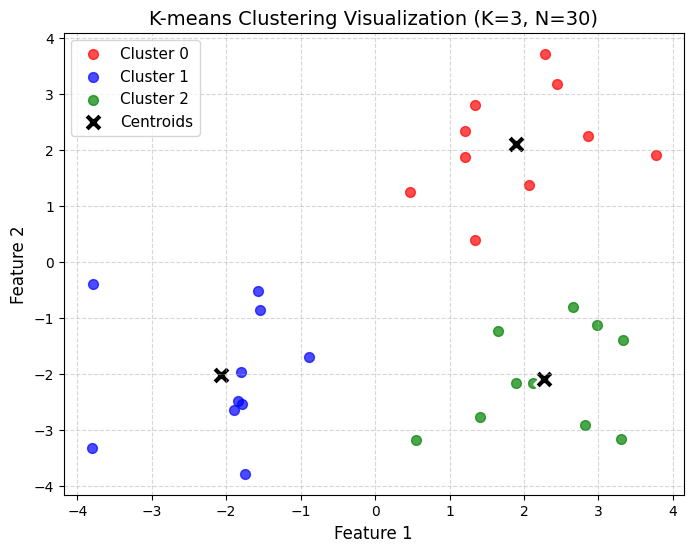

In [29]:
import torch
import matplotlib.pyplot as plt

# ==========================================
# 0. 数据准备 (30个二维数据点)
# ==========================================
torch.manual_seed(1)  # 固定随机种子以确保结果可复现

# 模拟生成3个不同中心的数据堆，每堆10个点，总共30个点
cluster1 = torch.randn(10, 2) + torch.tensor([2.0, 2.0])
cluster2 = torch.randn(10, 2) + torch.tensor([-2.0, -2.0])
cluster3 = torch.randn(10, 2) + torch.tensor([2.0, -2.0])

# 拼接成一个形状为 (30, 2) 的数据矩阵
X = torch.cat([cluster1, cluster2, cluster3], dim=0)

# ==========================================
# 1. 调用前面定义的 kmeans_torch 函数
# ==========================================
K = 3
# 提示：此处的 kmeans_torch 即为上一轮对话中编写的纯优化函数
centroids, z = kmeans_torch(X, K=K, max_iters=100)

# ==========================================
# 2. 使用 matplotlib 进行结果可视化
# ==========================================
plt.figure(figsize=(8, 6))

# 定义 3 个簇的颜色
colors = ['red', 'blue', 'green']

# 1. 绘制 30 个原始数据点，根据算法预测的标签 z 进行着色
for k in range(K):
    cluster_data = X[z == k]
    plt.scatter(cluster_data[:, 0].numpy(), cluster_data[:, 1].numpy(), 
                c=colors[k], label=f'Cluster {k}', s=50, alpha=0.7)

# 2. 绘制 K-means 算法最终收敛出的 3 个中心点 (Centroids)
plt.scatter(centroids[:, 0].numpy(), centroids[:, 1].numpy(), 
            c='black', marker='X', s=200, label='Centroids', edgecolors='white', linewidths=2)

# 美化图表
plt.title(f"K-means Clustering Visualization (K={K}, N={X.shape[0]})", fontsize=14)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

# 显示图像
plt.show()